In [1]:
import shap
import lightgbm as lgb
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
import numpy as np

In [2]:
labelled_df = pd.read_parquet('train_labelled.parquet', engine='pyarrow')
labelled_df.head()

,clean_text,party,sentiment,sentiment_score
0,maga maha trumpvance2024 trump2024 magamovemen...,republican,positive,0.8479
1,favorite post kamala harris pretending like de...,democrat,positive,0.8545
2,ron desantis signed sb304 price gouging back a...,democrat,positive,0.8979
3,200 people dead hurricane 99 republican voted ...,republican,negative,-0.8662
4,wtaf coward afraid 60 minute 're incapable tel...,republican,negative,-0.9712


In [3]:
print(labelled_df.shape[0])

864378


## Party Classifier

In [21]:
party_model = joblib.load("models/LightGBM_party_classifier.joblib")

tfidf = party_model.named_steps['tfidf']
lgb_model = party_model.named_steps['clf']

sample_idx = np.random.choice(labelled_df.shape[0], 10000, replace=False)
sample_texts = labelled_df['clean_text'].iloc[sample_idx]

X_sample = tfidf.transform(sample_texts)

print(X_sample.shape)

(10000, 20000)


/home/tsaddi01/.local/lib/python3.10/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


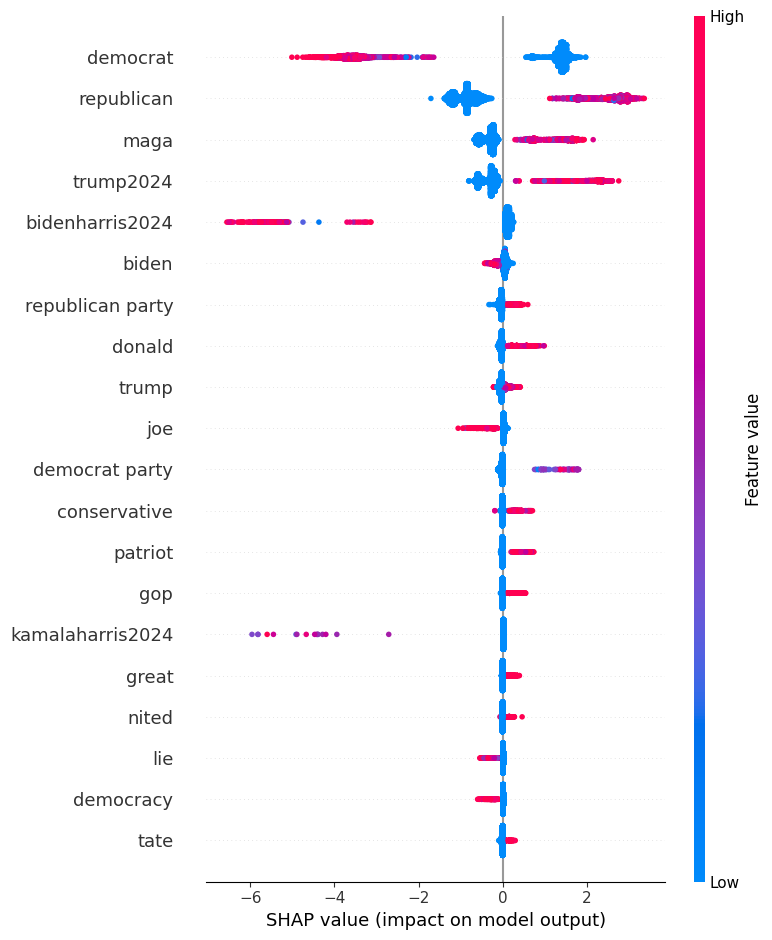

In [22]:
X_sample_dense = X_sample.toarray()

explainer = shap.TreeExplainer(lgb_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample_dense)

# Plot
shap.summary_plot(
    shap_values,
    X_sample_dense,
    feature_names=tfidf.get_feature_names_out()
)


In [30]:
target_shap_values = np.array(shap_values)
    
print(f"Target SHAP matrix shape being used: {target_shap_values.shape}")

Target SHAP matrix shape being used: (10000, 20000)


In [35]:
mean_abs_shap = np.mean(np.abs(target_shap_values), axis=0)
N_features_in_shap = len(mean_abs_shap)

feature_names_full = tfidf.get_feature_names_out()


In [37]:
print("Global Feature Importance (Top 10 by Mean Absolute SHAP)")
mean_abs_shap = np.mean(np.abs(target_shap_values), axis=0)

global_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Abs_SHAP': mean_abs_shap
}).sort_values(by='Mean_Abs_SHAP', ascending=False)

global_importance_df.head(10)


Global Feature Importance (Top 10 by Mean Absolute SHAP)


,Feature,Mean_Abs_SHAP
4524,democrat,1.986908
14385,republican,1.361204
10584,maga,0.534168
18123,trump2024,0.515446
2316,bidenharris2024,0.230435
1903,biden,0.073952
14547,republican party,0.065104
5300,donald,0.064475
17653,trump,0.063317
9226,joe,0.047744


In [38]:
print("Directional Feature Importance (Top 10 by Mean Signed SHAP)")
mean_signed_shap = np.mean(target_shap_values, axis=0)

directional_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Signed_SHAP': mean_signed_shap
}).sort_values(by='Mean_Signed_SHAP', ascending=False)

# Show the strongest positive (Republican) signals
print("Strongest Positive Signals (Republican):")
directional_importance_df.head(5)



Directional Feature Importance (Top 10 by Mean Signed SHAP)
Strongest Positive Signals (Republican):


,Feature,Mean_Signed_SHAP
14385,republican,0.102400
4524,democrat,0.058428
17653,trump,0.004550
9365,kamalaharris2024,0.003586
11903,nited tate,0.002210


In [39]:
print("Strongest Negative Signals (Democratic):")
directional_importance_df.tail(5)


Strongest Negative Signals (Democratic):


,Feature,Mean_Signed_SHAP
5300,donald,-0.005933
12456,party,-0.006945
14547,republican party,-0.009551
4762,democrat party,-0.009860
18123,trump2024,-0.062521


In [45]:
# Measures what percentage of the time a feature's presence drives the prediction positively.
print("Consistency (Top 10 by Positive Attribution Rate)")

consistency_data = []

for j, feature in enumerate(feature_names):
    
    feature_present_data = X_sample_dense[:, j]
    feature_present_mask = feature_present_data > 0
    total_present_count = np.sum(feature_present_mask)    
    
    if total_present_count > 0:
        positive_impact_mask = target_shap_values[:, j] > 0        
        positive_attribution_count = np.sum(feature_present_mask & positive_impact_mask)        
        consistency = (positive_attribution_count / total_present_count) * 100
        consistency_data.append({
            'Feature': feature,
            'Positive_Attribution_Rate (%)': consistency,
            'Total_Count': total_present_count # useful for context
        })

consistency_df = pd.DataFrame(consistency_data).sort_values(
    by=['Positive_Attribution_Rate (%)', 'Total_Count'], ascending=False)

print(len(consistency_df[consistency_df['Positive_Attribution_Rate (%)'] == 100]))
# Display features that are highly consistent (near 100%) and appeared at least 50 times
consistency_df[consistency_df['Total_Count'] >= 50].head(10)


Consistency (Top 10 by Positive Attribution Rate)
387


,Feature,Positive_Attribution_Rate (%),Total_Count
13231,republican,100.0,2890
9728,maga,100.0,2194
16673,trump2024,100.0,1153
4878,donald,100.0,853
10944,nited tate,100.0,616
6928,gop,100.0,536
7042,great,100.0,510
8919,laughing,100.0,361
12395,president trump,100.0,217
11715,patriot,100.0,205


## Democrat Sentiment Classifier

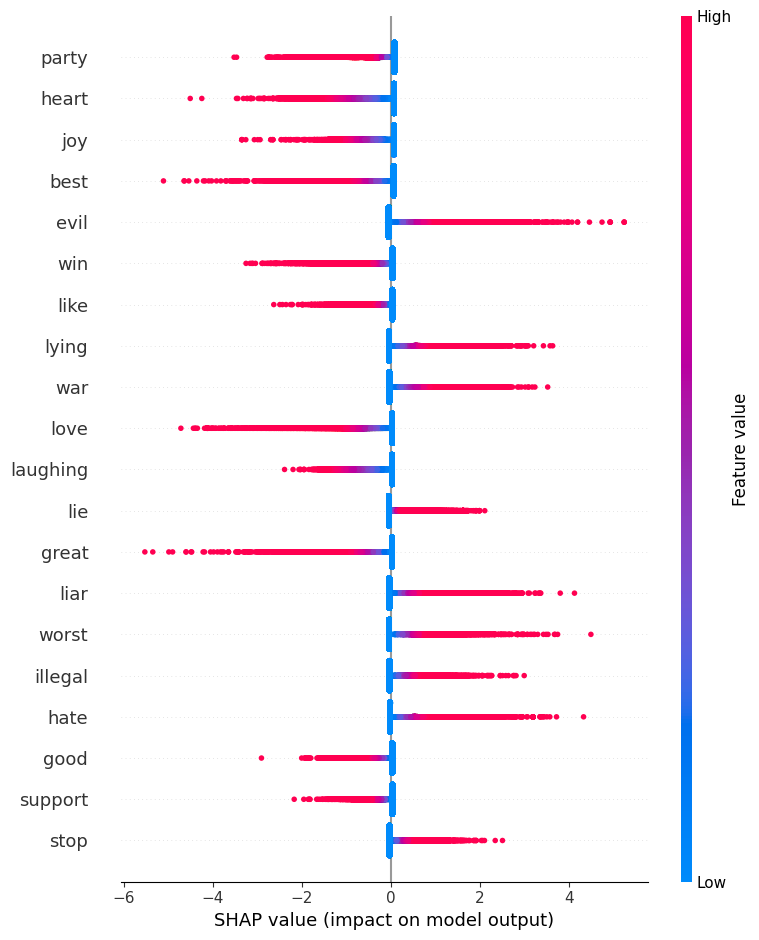

In [57]:
model = joblib.load("models/LinearSVC_democrat_sentiment_classifier.joblib")
tfidf = model.named_steps['tfidf']
clf = model.named_steps['clf']

democrat_df = labelled_df[labelled_df['party'] == 'democrat'].copy()

democrat_tfidf = tfidf.transform(democrat_df['clean_text'])

democrat_tfidf_dense = democrat_tfidf.toarray()

explainer = shap.LinearExplainer(clf, democrat_tfidf_dense)
shap_values = explainer.shap_values(democrat_tfidf_dense)
shap_values = -shap_values

shap.summary_plot(
    shap_values, 
    democrat_tfidf_dense, 
    feature_names=tfidf.get_feature_names_out(),
    title="SHAP Summary: Democratic Sentiment Classification"
)

In [53]:
target_shap_values = np.array(shap_values)
feature_names = tfidf.get_feature_names_out()
N_features_in_shap = target_shap_values.shape[1]
feature_names = feature_names[:N_features_in_shap]

print("Global Feature Importance (Top 10 by Mean Absolute SHAP)")
mean_abs_shap = np.mean(np.abs(target_shap_values), axis=0)

global_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Abs_SHAP': mean_abs_shap
}).sort_values(by='Mean_Abs_SHAP', ascending=False)

global_importance_df.head(10)

Global Feature Importance (Top 10 by Mean Absolute SHAP)


,Feature,Mean_Abs_SHAP
6462,party,0.125189
4422,heart,0.114906
5000,joy,0.095832
916,best,0.085548
3366,evil,0.076929
9744,win,0.076114
5387,like,0.071670
5563,lying,0.066301
9582,war,0.065182
5522,love,0.065068


In [56]:
class_labels = clf.classes_
print(class_labels)

['negative' 'positive']


In [54]:
print("Directional Feature Importance (Top 10 by Mean Signed SHAP)")
mean_signed_shap = np.mean(target_shap_values, axis=0)

directional_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Signed_SHAP': mean_signed_shap
}).sort_values(by='Mean_Signed_SHAP', ascending=False)

print("Strongest Positive Sentiment Signals:")
directional_importance_df.head(5)

Directional Feature Importance (Top 10 by Mean Signed SHAP)
Strongest Positive Sentiment Signals:


,Feature,Mean_Signed_SHAP
9868,worst,0.021218
3366,evil,0.019441
5337,lie,0.019374
5313,liar,0.013361
5091,killer,0.013134


In [55]:
print("Strongest Negative Sentiment Signals:")
directional_importance_df.tail(5)

Strongest Negative Sentiment Signals:


,Feature,Mean_Signed_SHAP
8601,terrorist,-0.015932
6462,party,-0.021003
4422,heart,-0.022570
916,best,-0.034491
5000,joy,-0.040457


## Republican Sentiment Classifier

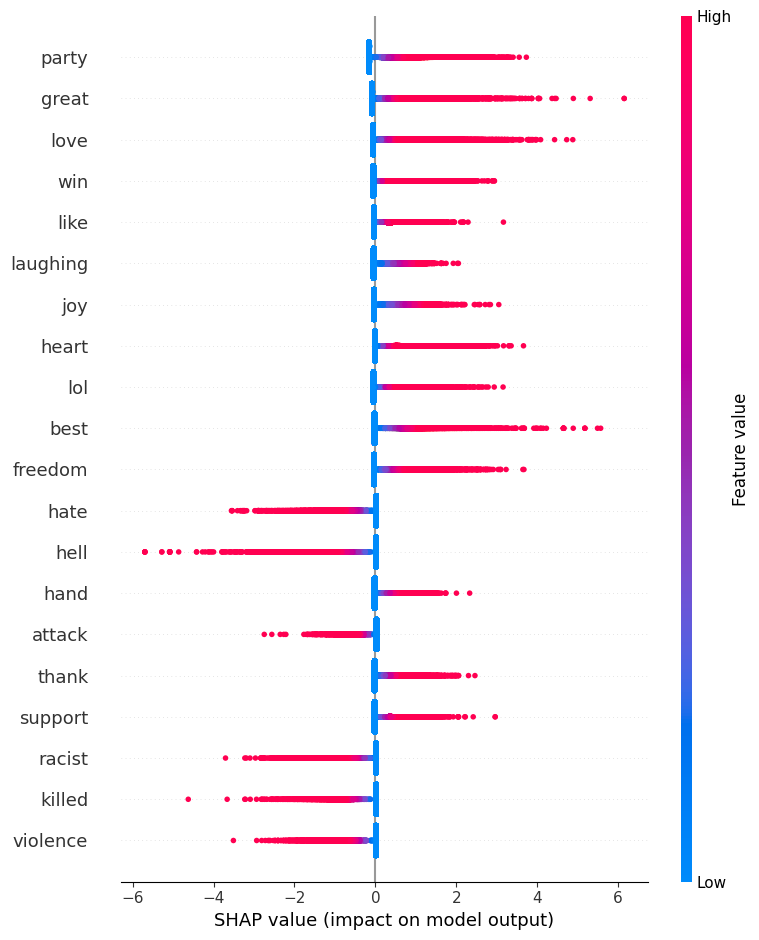

In [7]:

model = joblib.load("models/LinearSVC_republican_sentiment_classifier.joblib")
tfidf = model.named_steps['tfidf']
clf = model.named_steps['clf']

republican_df = labelled_df[labelled_df['party'] == 'republican'].copy()

republican_tfidf = tfidf.transform(republican_df['clean_text'])
republican_tfidf_dense = republican_tfidf.toarray()

explainer = shap.LinearExplainer(clf, republican_tfidf_dense)
shap_values = explainer.shap_values(republican_tfidf_dense)

shap.summary_plot(
    shap_values, 
    republican_tfidf_dense,
    feature_names=tfidf.get_feature_names_out(),
    title="SHAP Summary: Republican Sentiment Classification"
)